In [41]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

plt.style.use('default')
sns.set_theme()



In [42]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator

In [43]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [44]:
domain = "quadruped"

In [45]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [46]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [47]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

max_len = 186 # by looking at PPO runs

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    train_avg_episode_returns_history = run.scan_history(keys=["train/episode_reward"])
    train_avg_episode_reward = [
        row["train/episode_reward"] for row in train_avg_episode_returns_history
    ]

    update_steps_history = run.scan_history(keys=["train/update_step"])
    update_steps = [row["train/update_step"] for row in update_steps_history]

    steps_history = run.scan_history(keys=["train/step"])
    steps = [row["train/step"] for row in steps_history]

    if run.config["agent_name"] != "ppo":

        eval_avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
        eval_avg_episode_reward = [
            row["eval/episode_reward"] for row in eval_avg_episode_returns_history
        ]


    else:
        eval_avg_episode_reward = train_avg_episode_reward

    eval_update_steps = update_steps

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    if run.config["agent_name"] != "ppo":
        max_len = len(update_steps)

    print("len(update_steps): ", len(update_steps[:max_len]))
    print("len(train_avg_episode_reward: ", len(train_avg_episode_reward[:max_len]))

    if run.config["agent_name"] == "ppo":
        max_len = len(update_steps)
    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["train/step"] = steps[:max_len]
    temp["train/update_step"] = update_steps[:max_len]
    temp["train/episode_reward"] = train_avg_episode_reward[:max_len]

    temp["eval/episode_reward"] = eval_avg_episode_reward[:max_len]
    temp["eval/update_step"] = update_steps[:max_len]

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 541
idx: 0
idx: 10
idx: 20
sf_simple
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple
len(update_steps):  199
len(train_avg_episode_reward:  199
ddpg
len(update_steps):  199
len(train_avg_episode_reward:  199
idx: 30
ddpg
len(update_steps):  199
len(train_avg_episode_reward:  199
ddpg
len(update_steps):  199
len(train_avg_episode_reward:  199
ddpg
len(update_steps):  199
len(train_avg_episode_reward:  199
ddpg
len(update_steps):  199
len(train_avg_episode_reward:  199
idx: 40
sf_simple_beakers_params
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple_beakers_params
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple_beakers_params
len(update_steps):  199
len(train_avg_episode_reward:  199
sf_simple_beakers_params
le

In [48]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [49]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC","sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ppo": "PPO"
}

In [50]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [51]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [52]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [53]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [54]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [55]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [56]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [57]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [58]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [59]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [60]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ppo", agents_new_names["ppo"]
)

In [61]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['SF' 'TD3' 'SF + SC (Ours)' 'TD3 + SC' 'TD3 + EWC' 'SF + EWC'
 'SF + SC + Attention (Ours)' 'TD3 + CBP' 'TD3 + P-last' 'PPO']


In [62]:
print(runs_df)

                                              summary  \
0   {'train/step': [10000, 20000, 30000, 40000, 50...   
1   {'train/step': [10000, 20000, 30000, 40000, 50...   
2   {'train/step': [10000, 20000, 30000, 40000, 50...   
3   {'train/step': [10000, 20000, 30000, 40000, 50...   
4   {'train/step': [10000, 20000, 30000, 40000, 50...   
5   {'train/step': [10000, 20000, 30000, 40000, 50...   
6   {'train/step': [10000, 20000, 30000, 40000, 50...   
7   {'train/step': [10000, 20000, 30000, 40000, 50...   
8   {'train/step': [10000, 20000, 30000, 40000, 50...   
9   {'train/step': [10000, 20000, 30000, 40000, 50...   
10  {'train/step': [10000, 20000, 30000, 40000, 50...   
11  {'train/step': [10000, 20000, 30000, 40000, 50...   
12  {'train/step': [10000, 20000, 30000, 40000, 50...   
13  {'train/step': [10000, 20000, 30000, 40000, 50...   
14  {'train/step': [10000, 20000, 30000, 40000, 50...   
15  {'train/step': [10000, 20000, 30000, 40000, 50...   
16  {'train/step': [10000, 2000

In [63]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [64]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (54, 5)


In [65]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

                    agent_name  agent_seed  \
0                           SF         388   
1                           SF         485   
2                           SF          97   
3                           SF         291   
4                           SF         194   
5                          TD3         679   
6                          TD3         582   
7                          TD3         291   
8                          TD3          97   
9                          TD3         485   
10              SF + SC (Ours)         388   
11              SF + SC (Ours)         485   
12              SF + SC (Ours)          97   
13              SF + SC (Ours)         291   
14              SF + SC (Ours)         194   
15                    TD3 + SC         291   
16                    TD3 + SC         194   
17                    TD3 + SC         679   
18                    TD3 + SC         485   
19                    TD3 + SC          97   
20                   TD3 + EWC    

In [66]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "PPO": "#17becf",
    # "SF + SC": "#ff7f0e",
    # "DDPG + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "DDPG",
#     "ddpg_beakers_params_continuous": "DDPG + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "DDPG + Plasticity (last layer)",
#     "ddpg_online_ewc": "DDPG (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "DDPG + Plasticity",
# }

In [67]:
# FOR PPO ANALYSIS ONLY

print(runs_df.columns)

runs_df["train/episode_rewards_num"] = (
    runs_df["train/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "train/step"])

runs_df["train/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["train/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["train/norm_cum_reward"] = runs_df["train/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')


In [68]:
# FOR PPO ANALYSIS ONLY

print(runs_df.columns)

runs_df["train/episode_rewards_num"] = (
    runs_df["train/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "train/step"])

runs_df["train/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["train/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["train/norm_cum_reward"] = runs_df["train/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')


In [69]:
print(runs_df[runs_df["agent_name"] == agents_new_names["ppo"]]["train/update_step"][:-24])
print(runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]]["train/update_step"].max())

9353          0
9354       2720
9355       8160
9356      13600
9357      19040
          ...  
10626    855840
10627    861280
10628    866720
10629    872160
10630    877600
Name: train/update_step, Length: 1278, dtype: object
990500.7499250075


In [70]:
runs_df[runs_df["agent_name"] == agents_new_names["ppo"]] = runs_df[runs_df["agent_name"] == agents_new_names["ppo"]][runs_df[runs_df["agent_name"] == agents_new_names["ppo"]]["train/update_step"] <= 990500]

In [71]:
from scipy.integrate import trapezoid

def compute_auc(group):
    return trapezoid(group["train/episode_reward"], group["train/update_step"])

In [72]:
runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "train/update_step"
] = runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "train/update_step"
].values

runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "eval/update_step"
] = runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "eval/update_step"
].values

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_90148/4073506129.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_90148/4073506129.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)
/var

7     7.647816e+08
8     6.087803e+08
9     3.879837e+08
10    2.475250e+08
11    2.361571e+08
Name: AUC, dtype: float64


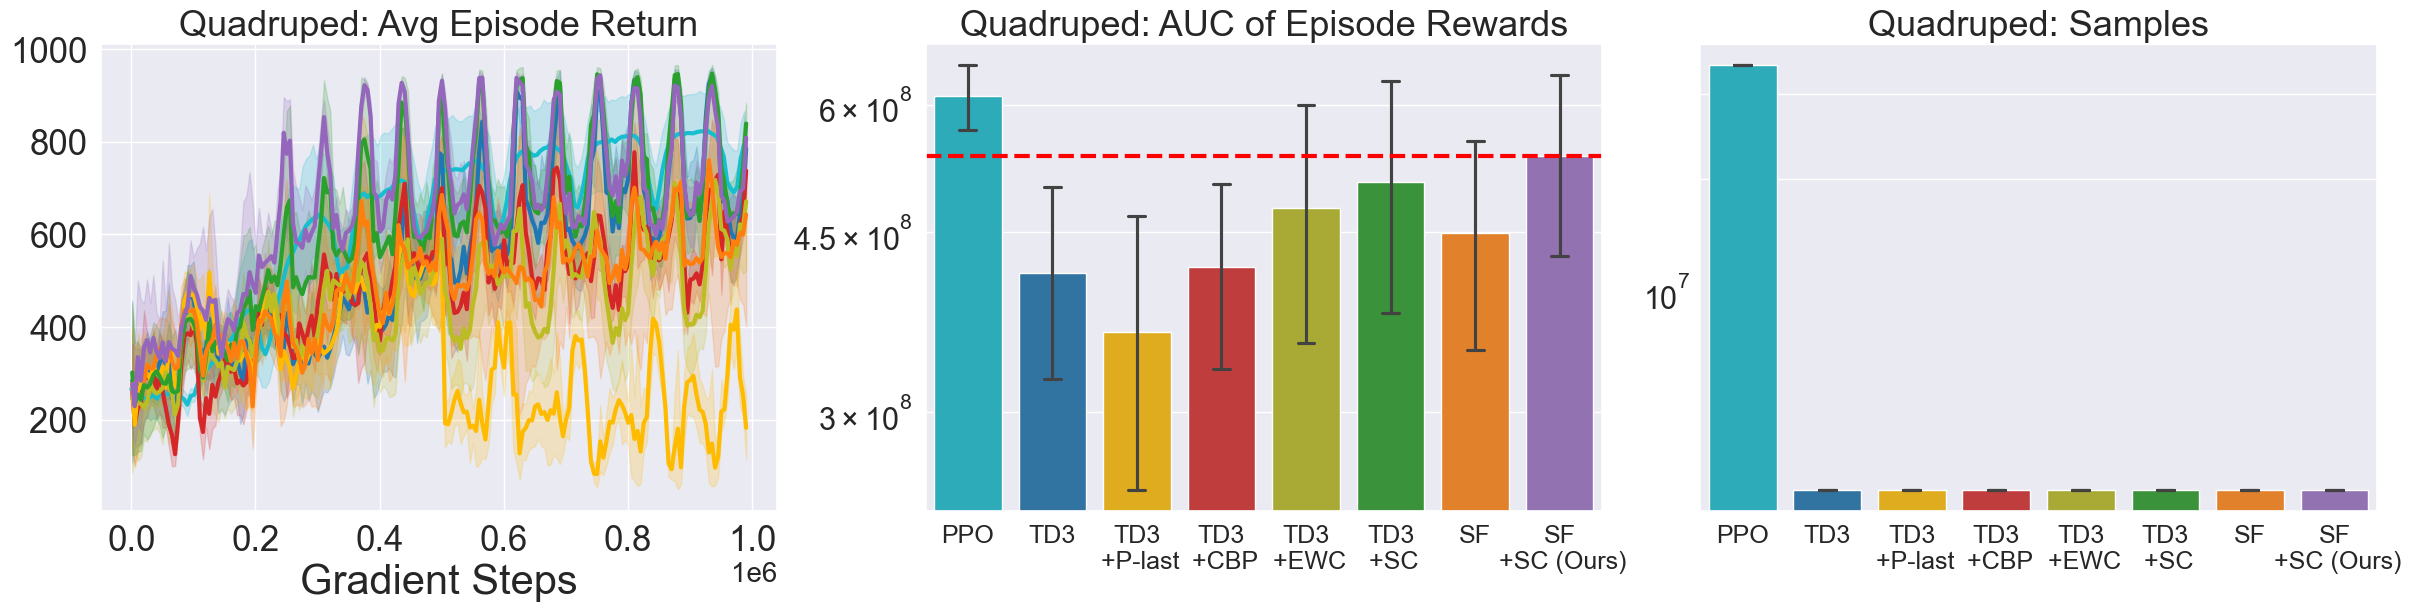

In [73]:
# FOR PPO ANALYSIS ONLY

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ppo"]],
    label=agents_new_names["ppo"],
    color=color_code[agents_new_names["ppo"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)

# agents_to_plot = ["PPO", "DDPG", "SF", "DDPG + SC", "SF + SC (Ours)",]
agents_to_plot = ["PPO", "TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]

auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)

print(subset[subset["agent_name"] == agents_new_names["sf_simple"]]["AUC"])

eps = 1e-12  # in case any values are 0
subset = subset.copy()
# subset["AUC_log10"] = np.log10(subset["AUC"].clip(lower=eps))

# print(subset[subset["agent_name"] == agents_new_names["sf_simple"]]["AUC_log10"])




sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)


subset_last_rows = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
subset_last_rows["agent_name_pretty"] = pd.Categorical(subset_last_rows["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)
sns.barplot(data=subset_last_rows, x="agent_name_pretty", y="train/step", palette=color_code, ax=axes[2], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

# for i, bar in enumerate(axes[1].patches):
#     x = bar.get_x()
#     y = bar.get_y()
#     w = bar.get_width()
#     h = bar.get_height()
#     if i % 2 == 0:
#         before = h
#     else:
#         pct_gain = 100 * (h - before) / before
#         if pct_gain > 0:
#             axes[1].text(
#                 bar.get_x() + bar.get_width()/2,
#                 bar.get_height() - 0.2 * axes[1].get_ylim()[1],
#                 f"+{pct_gain:.1f}%",
#                 ha="center", va="top", fontsize=25, fontweight="bold"
#             )
#
#         else:
#             axes[1].text(
#                 bar.get_x() + bar.get_width()/2,
#                 bar.get_height() - 0.2 * axes[1].get_ylim()[1],
#                 f"-{pct_gain:.1f}%",
#                 ha="center", va="top", fontsize=25, fontweight="bold"
#             )
#
#
#     print(i, x, y, w, h)

axes[0].set_title("Quadruped: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Gradient Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="lower right", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=22)
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Quadruped: AUC of Episode Rewards", fontsize=26)
axes[1].tick_params(axis="x", labelsize=18)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[1].tick_params(axis='y', which='minor', labelsize=0)


mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[2].set_xlabel("", fontsize=14)
axes[2].set_ylabel("", fontsize=14)
axes[2].set_title("Quadruped: Samples", fontsize=26)
axes[2].tick_params(axis="x", labelsize=18)
axes[2].tick_params(axis="y", labelsize=22)
axes[2].set_yscale("log")
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[2].yaxis.get_offset_text().set_fontsize(18)
axes[2].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[], numticks=10))
axes[2].tick_params(axis='y', which='minor', labelsize=22)

filename = "ppo_comparison_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()
